<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


In [130]:
#import piplite
#await piplite.install(['numpy'],['pandas'])
#await piplite.install(['seaborn'])

In [131]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [132]:
#from js import fetch
#import io

#URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
#resp = await fetch(URL)
#boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())
#boston_df=pd.read_csv(boston_url)

In [133]:
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
boston_df = pd.read_csv(URL)
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


## Add your code below following the instructions given in the course to complete the peer graded assignment


## Task 1: Familiarize Yourself with the Dataset

### 1.	Display the first 5 rows of the dataset.

In [134]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


### 2.	Display the data types of each column.

In [135]:
boston_df.dtypes

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

### 3.	Check for missing values in each column.

In [136]:
missing_values = boston_df.isnull().sum()
print(missing_values)

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64


### 4.	Check for duplicate rows.

In [137]:
duplicate_rows = boston_df[boston_df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [Unnamed: 0, CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, LSTAT, MEDV]
Index: []


### 5.	Display the correlation matrix of the dataset.

In [138]:
corr_matrix = boston_df.corr()
print(corr_matrix)

            Unnamed: 0      CRIM        ZN     INDUS      CHAS       NOX  \
Unnamed: 0    1.000000  0.407407 -0.103393  0.399439 -0.003759  0.398736   
CRIM          0.407407  1.000000 -0.200469  0.406583 -0.055892  0.420972   
ZN           -0.103393 -0.200469  1.000000 -0.533828 -0.042697 -0.516604   
INDUS         0.399439  0.406583 -0.533828  1.000000  0.062938  0.763651   
CHAS         -0.003759 -0.055892 -0.042697  0.062938  1.000000  0.091203   
NOX           0.398736  0.420972 -0.516604  0.763651  0.091203  1.000000   
RM           -0.079971 -0.219247  0.311991 -0.391676  0.091251 -0.302188   
AGE           0.203784  0.352734 -0.569537  0.644779  0.086518  0.731470   
DIS          -0.302211 -0.379670  0.664408 -0.708027 -0.099176 -0.769230   
RAD           0.686002  0.625505 -0.311948  0.595129 -0.007368  0.611441   
TAX           0.666626  0.582764 -0.314563  0.720760 -0.035587  0.668023   
PTRATIO       0.291074  0.289946 -0.391679  0.383248 -0.121515  0.188933   
LSTAT       

## Task 2: Generate Descriptive Statistics and Visualizations

### 1.	Display descriptive statistics of the dataset.

In [139]:
boston_df.describe(include = "all")

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


### 2.	Create a boxplot for MEDV (Median value of owner-occupied homes).

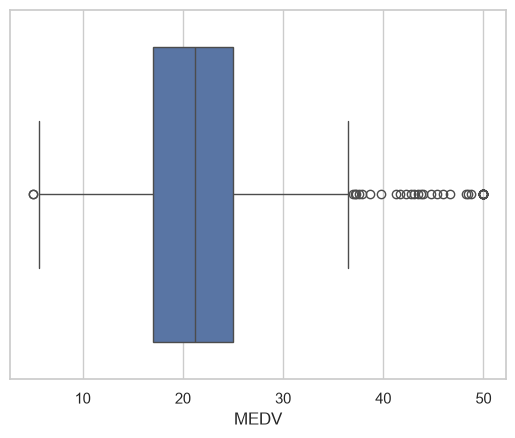

In [140]:
sns.set(style="whitegrid")
boxp_MEDV = sns.boxplot(x="MEDV", data=boston_df)
pyplot.show()

### 3.	Create a bar plot for CHAS (Charles River dummy variable).

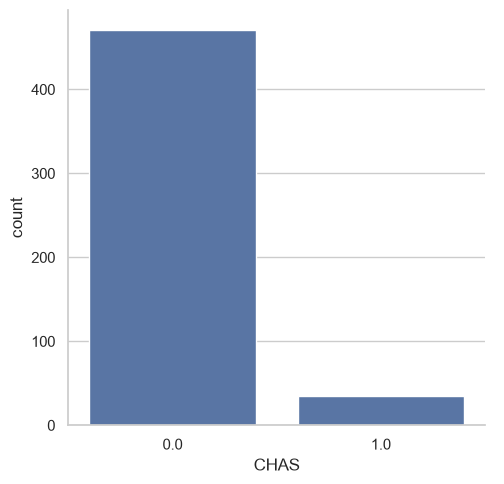

In [141]:
barplot_CHAS = sns.catplot(x="CHAS", kind= "count", data=boston_df)
pyplot.show()

### 4.	Discretize AGE into three groups and create a boxplot of MEDV versus these groups:

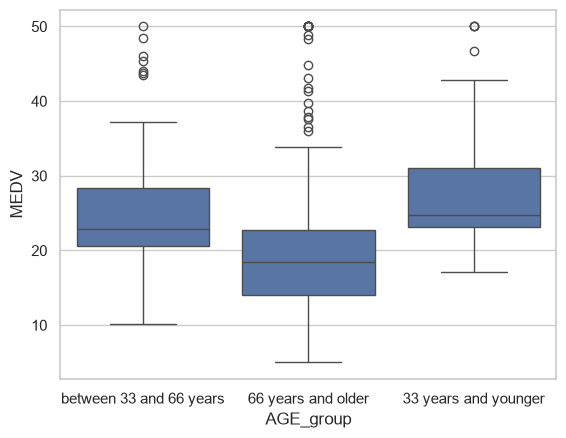

In [142]:
#Discretizing the variable AGE into three groups
#Group 1: age ranges of below 33 years
#Group 2: age is between 33 and 66 years
#Group 3: age 66 years and older
boston_df.loc[(boston_df['AGE'] <= 33), 'AGE_group'] = '33 years and younger'
boston_df.loc[(boston_df['AGE'] > 33)&(boston_df['AGE'] < 66), 'AGE_group'] = 'between 33 and 66 years'
boston_df.loc[(boston_df['AGE'] >= 66), 'AGE_group'] = '66 years and older'


#Creating a boxplot of MEDV versus the newly created variable age_group
#boxp_MEDV = sns.boxplot(x="MEDV", y= "AGE_group", data=boston_df)
boxp_MEDV = sns.boxplot(x="AGE_group", y= "MEDV", data=boston_df)
pyplot.show()

### 5.	Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres).

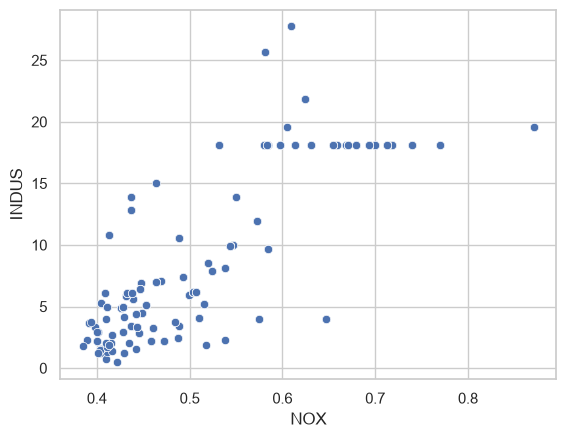

In [143]:
scatplot_NOX_INDUS = sns.scatterplot(x='NOX', y='INDUS', data=boston_df)
pyplot.show()

### 6.	Create a histogram for PTRATIO (pupil-teacher ratio).

/var/folders/4x/y3_8vmmj3wv75sfw87w4hr000000gn/T/ipykernel_2148/4079551891.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  histogram_PTRATIO = sns.distplot(boston_df['PTRATIO'], kde=False,)


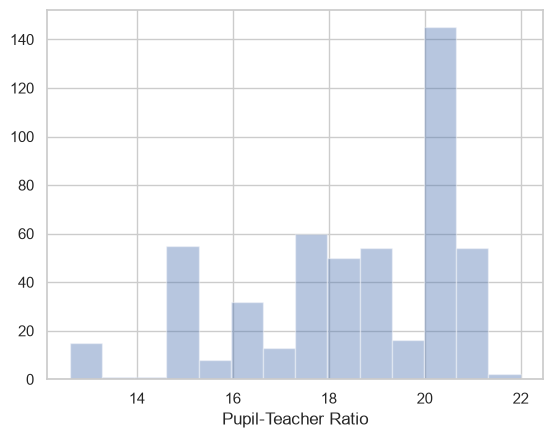

In [144]:
histogram_PTRATIO = sns.distplot(boston_df['PTRATIO'], kde=False,)
histogram_PTRATIO.set(xlabel='Pupil-Teacher Ratio')
pyplot.show()

## Task 3: Apply Statistical Tests

### 1.	Use Levene’s test to check if the variances of MEDV for homes bounded by the Charles River (CHAS = 1) and those not bounded (CHAS = 0) are equal.


In [145]:
stats.levene(boston_df[boston_df['CHAS'] == '0']['MEDV'],
                   boston_df[boston_df['CHAS'] == '1']['MEDV'], center='mean')

/var/folders/4x/y3_8vmmj3wv75sfw87w4hr000000gn/T/ipykernel_2148/1231871306.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stats.levene(boston_df[boston_df['CHAS'] == '0']['MEDV'],


LeveneResult(statistic=np.float64(nan), pvalue=np.float64(nan))

As displayed by the error message above, the category "0" of the CHAS variable does not meet the required sample size to perform the Levene's test of scipy.stats and thus, Python returns only NaN values. 

### 2.	Perform a T-test to determine if there is a significant difference in MEDV between homes bounded and not bounded by the Charles River.

In [146]:
stats.ttest_ind(boston_df[boston_df['CHAS'] == '0']['MEDV'],
                   boston_df[boston_df['CHAS'] == '1']['MEDV'], equal_var = True)

/var/folders/4x/y3_8vmmj3wv75sfw87w4hr000000gn/T/ipykernel_2148/404401162.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stats.ttest_ind(boston_df[boston_df['CHAS'] == '0']['MEDV'],


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

As displayed by the error message above, the category "0" of the CHAS variable does not meet the required sample size to perform a T test of scipy.stats and thus, Python returns only NaN values.

### 3.	Conduct an ANOVA test to compare MEDV among the three AGE groups created earlier.

In [147]:
#Separating the three samples (one for each age group) into a variable each.
thirtythree_lower = boston_df[boston_df['AGE_group'] == '33 years and younger']['MEDV']
thirtythree_sixtysix = boston_df[boston_df['AGE_group'] == 'between 33 and 66 years']['MEDV']
sixtysix_older = boston_df[boston_df['AGE_group'] == '66 years and older']['MEDV']

#Running the ANOVA
f_statistic, p_value = stats.f_oneway(thirtythree_lower, thirtythree_sixtysix, sixtysix_older)
print("F_Statistic: {0}, P-Value: {1}".format(f_statistic,p_value))

F_Statistic: 32.2868064078215, P-Value: 6.423413089230489e-14


The **p-value is 6.423413089230489e-14**, which is below a significance level of α = 0.05 and is thus highly significant. This means that there are **significant differences** in the MEDV among the three different AGE groups and we consequently **reject the null hypothesis**. 

### 4.	Perform a Pearson correlation test to assess the relationship between NOX and INDUS.

In [148]:
stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

PearsonRResult(statistic=np.float64(0.7636514469209152), pvalue=np.float64(7.91336106123953e-98))

The p-value is **p = 7.91336106123953e-98**, which is below a significance level of α = 0.05, meaning that NOX and INDUS have a significant relationship with each other. Additionally, ***Pearson's r* = 0.76 (rounded to second decimal)**, meaning that NOX and INDUS have a **significant, positive and strong relationship** with each other. 

### 5.	Fit a simple linear regression model to evaluate the impact of DIS (distance to employment centres) on MEDV. Report and interpret the regression results.

In [150]:
X = boston_df['DIS']
y = boston_df['MEDV']
X = sm.add_constant(X) 

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.21e-08
Time:                        11:27:32   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The **p-value** (the value in the cell **Prob (F-statistic): 1.21e-08**), which is below a significance level of α = 0.05, meaning that **DIS has a significant impact on MEDV**. Additionally, the **R-squared = 0.062** and √0.062 = 0.248998, meaning that the **correlation between DIS and MEDV is 0.25 (rounded to second decimal)**. This means that **DIS has a significant, positive, mid-sized effect on MEDV**. 